# Tutorial 1 — Standalone sparse NMF

This notebook walks through the simplest use of
`sparse_nmf.SparseNMF` on the bundled synthetic dataset.
We fit a rank-8 model, then check the recovered factors
and reconstruction quality.

Run order: top to bottom. All cells should execute in a
few seconds on CPU.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sparse_nmf import SparseNMF
from sparse_nmf.data import generate_synthetic_sparse

np.random.seed(0)
X = generate_synthetic_sparse(
    n_samples=500, n_features=1_000, n_components=8,
    density=0.05, seed=0,
)
print(f'shape={X.shape}  nnz={X.nnz:,}  density={X.nnz / (X.shape[0]*X.shape[1]):.3%}')

shape=(500, 1000)  nnz=25,000  density=5.000%


## Fit the model

200 multiplicative-update iterations is enough for this
small matrix. On real data you'll typically want 500 +
and a CUDA device.

In [2]:
nmf = SparseNMF(n_components=8, max_iter=200, device='cpu', verbose=False)
W = nmf.fit_transform(X)
H = nmf.H.detach().cpu().numpy()
print(f'W.shape={W.shape}  H.shape={H.shape}')
print(f'W non-negative: {(W >= 0).all()}')
print(f'H non-negative: {(H >= 0).all()}')

/private/tmp/sparseNMF/src/sparse_nmf/_core.py:339: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  sparse_tensor = torch.sparse_coo_tensor(


W.shape=(500, 8)  H.shape=(8, 1000)
W non-negative: True
H non-negative: True


## Reconstruction quality

On a rank-8 planted matrix with light noise, NMF should
land within ~30-40% relative Frobenius error.

In [3]:
X_dense = X.toarray()
recon = W @ H
rel_err = np.linalg.norm(X_dense - recon) / np.linalg.norm(X_dense)
print(f'relative reconstruction error: {rel_err:.4f}')

relative reconstruction error: 0.5180


## Visualize the per-sample codes

The columns of `W` are the latent factor activations.
Heatmap of the first 50 samples × 8 factors:

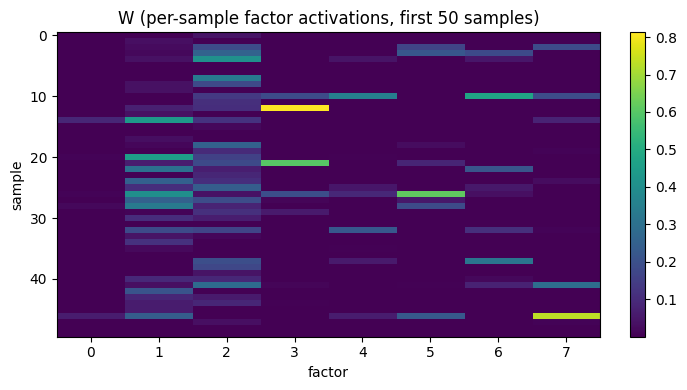

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(W[:50], aspect='auto', cmap='viridis')
ax.set_xlabel('factor')
ax.set_ylabel('sample')
ax.set_title('W (per-sample factor activations, first 50 samples)')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Visualize the per-feature loadings

The rows of `H` show which features each factor activates.
We pick the top 30 features per factor for readability:

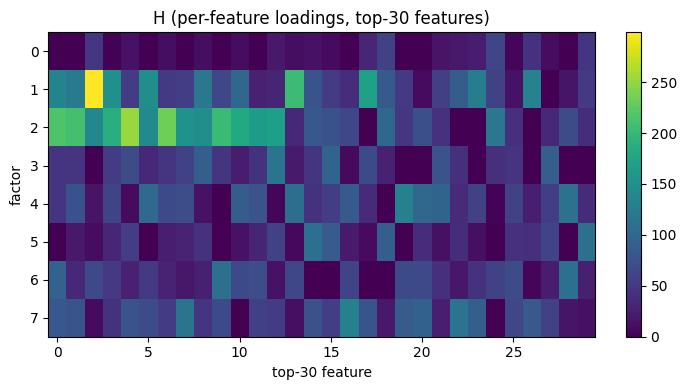

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
top_features = np.argsort(H.sum(axis=0))[::-1][:30]
im = ax.imshow(H[:, top_features], aspect='auto', cmap='viridis')
ax.set_xlabel('top-30 feature')
ax.set_ylabel('factor')
ax.set_title('H (per-feature loadings, top-30 features)')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Next

Tutorial 2 (`02_joint_model.ipynb`) wraps this same NMF
factorization inside an autoencoder so you get a
low-dimensional embedding directly, without a separate
post-NMF dimensionality-reduction step.